In [2]:
import statsmodels.api as sm
from statsmodels.formula.api import ols
import seaborn as sns
import matplotlib.pyplot as plt
!pip install pycountry-convert
import pycountry_convert as pc
import pandas as pd
import requests

In [3]:
df1 = pd.read_csv("covid19_statistics")
df1.head()

,Unnamed: 0,continent,country,cases.active,cases.critical,cases.recovered,cases.total,deaths.total,population(k),test.total (k),date,time_hms
0,0,South-America,Falkland-Islands,0.0,NaN,1930.0,1930,NaN,3.539,8.632,2026-03-03,23:45:09
1,1,North-America,Montserrat,19.0,NaN,1376.0,1403,8.0,4.965,17.762,2026-03-03,23:45:09
2,2,NaN,Diamond-Princess,0.0,NaN,699.0,712,13.0,NaN,NaN,2026-03-03,23:45:09
3,3,Europe,Vatican-City,0.0,NaN,29.0,29,NaN,0.799,NaN,2026-03-03,23:45:09
4,4,Africa,Western-Sahara,0.0,NaN,9.0,10,1.0,626.161,NaN,2026-03-03,23:45:09


In [4]:
df2 = df1[['continent', 'country', 'cases.total', 'deaths.total', 'population(k)', 'test.total (k)']].dropna()
df2.head()

,continent,country,cases.total,deaths.total,population(k),test.total (k)
1,North-America,Montserrat,1403,8.0,4.965,17.762
6,Asia,China,503302,5272.0,1448471.400,160000.000
7,Oceania,Nauru,5393,1.0,10.903,20.509
8,Oceania,Wallis-and-Futuna,3550,8.0,10.982,20.508
9,North-America,St-Barth,5507,6.0,9.945,78.646


In [5]:
model = ols('Q("deaths.total") ~ Q("cases.total")', data=df2).fit()
print (model.summary())

                            OLS Regression Results                            
Dep. Variable:      Q("deaths.total")   R-squared:                       0.785
Model:                            OLS   Adj. R-squared:                  0.784
Method:                 Least Squares   F-statistic:                     766.5
Date:                Fri, 24 Apr 2026   Prob (F-statistic):           5.15e-72
Time:                        22:00:32   Log-Likelihood:                -2605.3
No. Observations:                 212   AIC:                             5215.
Df Residuals:                     210   BIC:                             5221.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                       coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------
Intercept         1168.4955   3806.849  

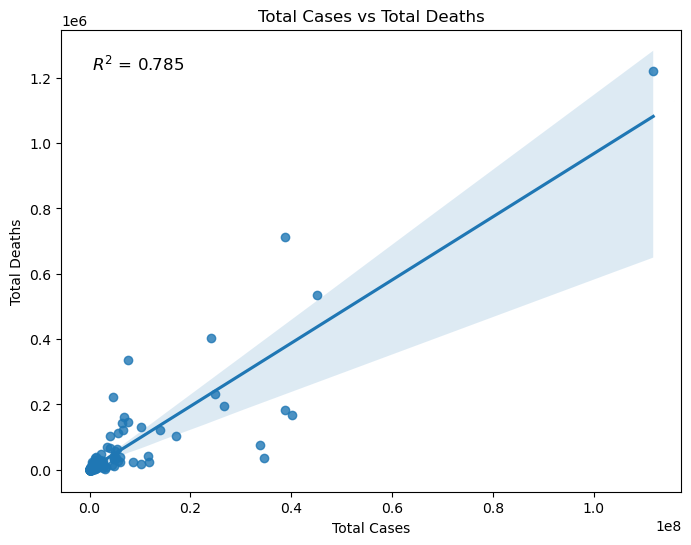

In [6]:
plt.figure(figsize=(8,6))

# Scatter + regression line
sns.regplot(x = 'cases.total', y = 'deaths.total', data = df2)

# Get R2 from model
r_squared = model.rsquared

# Add R2 text to plot
plt.text(
    0.05, 0.95,
    f'$R^2$ = {r_squared:.3f}',
    transform = plt.gca().transAxes,
    fontsize = 12,
    verticalalignment = 'top')

plt.title('Total Cases vs Total Deaths')
plt.xlabel('Total Cases')
plt.ylabel('Total Deaths')
plt.show()

In [7]:
# Keep only needed columns
df_clean = df2[['continent', 'cases.total', 'deaths.total']].dropna()

# Fit ANOVA model
model = ols('Q("deaths.total") ~ Q("cases.total") + C(continent)', data=df_clean).fit()

# ANOVA table
anova_table = sm.stats.anova_lm(model, typ=2)

print(anova_table)

                        sum_sq     df           F        PR(>F)
C(continent)      5.083292e+10    5.0    3.893512  2.155526e-03
Q("cases.total")  2.056636e+12    1.0  787.632992  3.794460e-72
Residual          5.352879e+11  205.0         NaN           NaN


<function matplotlib.pyplot.show(close=None, block=None)>

<Figure size 640x480 with 0 Axes>

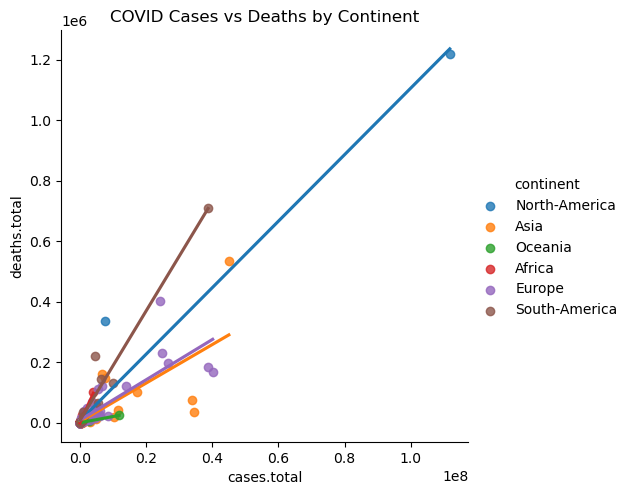

In [8]:
plt.figure()

sns.lmplot(
    data = df_clean,
    x = 'cases.total',
    y = 'deaths.total',
    hue = 'continent',
    ci = None)

plt.title('COVID Cases vs Deaths by Continent')
plt.show

Observation: Regional Clustering - Each continent has a data cluster. This shows that countries within the same continent tend to have similar case-death patterns, possibly due to geographic, demographic, or policy similarities.

<function matplotlib.pyplot.show(close=None, block=None)>

<Figure size 640x480 with 0 Axes>

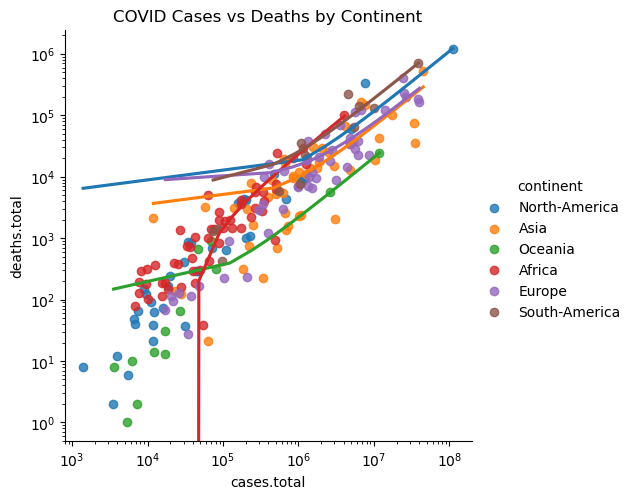

In [9]:
plt.figure()

sns.lmplot(
    data = df_clean,
    x = 'cases.total',
    y = 'deaths.total',
    hue = 'continent',
    ci = None)

plt.xscale('log')
plt.yscale('log')

plt.title('COVID Cases vs Deaths by Continent')
plt.show

In [10]:
# Display maxrows = pd.set_option('display.max_rows', None)
# Reset display maxrows = pd.reset_option('display.max_rows')

pd.set_option('display.max_rows', None)


In [11]:
df3 = pd.read_csv('Worldwide Vaccine Data.csv')
df3.head()

,Country,Doses administered per 100 people,Total doses administered,% of population vaccinated,% of population fully vaccinated
0,Afghanistan,33,12526397,30.0,28.0
1,Albania,106,3025728,47.0,44.0
2,Algeria,35,15267442,18.0,15.0
3,Angola,74,23701049,47.0,26.0
4,Argentina,252,113272665,92.0,84.0


In [12]:
def country_to_continent(country_name):
    try:
        country_alpha2 = pc.country_name_to_country_alpha2(country_name)
        continent_code = pc.country_alpha2_to_continent_code(country_alpha2)
        continent_name = pc.convert_continent_code_to_continent_name(continent_code)
        return continent_name
    except:
        return None

df3['Continent'] = df3['Country'].apply(country_to_continent)

cols = list(df3.columns)
cols.remove("Continent")
cols.insert(0, "Continent")

df3 = df3[cols]
df3 = df3.sort_values(by = "Continent").reset_index(drop=True)

df3.head()

,Continent,Country,Doses administered per 100 people,Total doses administered,% of population vaccinated,% of population fully vaccinated
0,Africa,Zimbabwe,83,12222754,44.0,32.0
1,Africa,Central African Republic,50,2354281,42.0,41.0
2,Africa,Chad,24,3891785,24.0,23.0
3,Africa,Malawi,34,6367571,25.0,20.0
4,Africa,São Tomé and Príncipe,106,227825,59.0,48.0


In [13]:
df3.describe()
df3.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 187 entries, 0 to 186
Data columns (total 6 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   Continent                          180 non-null    object 
 1   Country                            187 non-null    object 
 2   Doses administered per 100 people  187 non-null    int64  
 3   Total doses administered           187 non-null    int64  
 4   % of population vaccinated         187 non-null    float64
 5   % of population fully vaccinated   187 non-null    float64
dtypes: float64(2), int64(2), object(2)
memory usage: 8.9+ KB


In [14]:
continent_avg = df3.groupby("Continent")[[
    "% of population vaccinated",
    "% of population fully vaccinated"
]].mean()

continent_avg

,% of population vaccinated,% of population fully vaccinated
Continent,,
Africa,39.073077,32.646154
Asia,69.445652,64.686957
Europe,66.342105,64.184211
North America,62.742857,56.766667
Oceania,69.109091,62.227273
South America,78.000000,69.333333


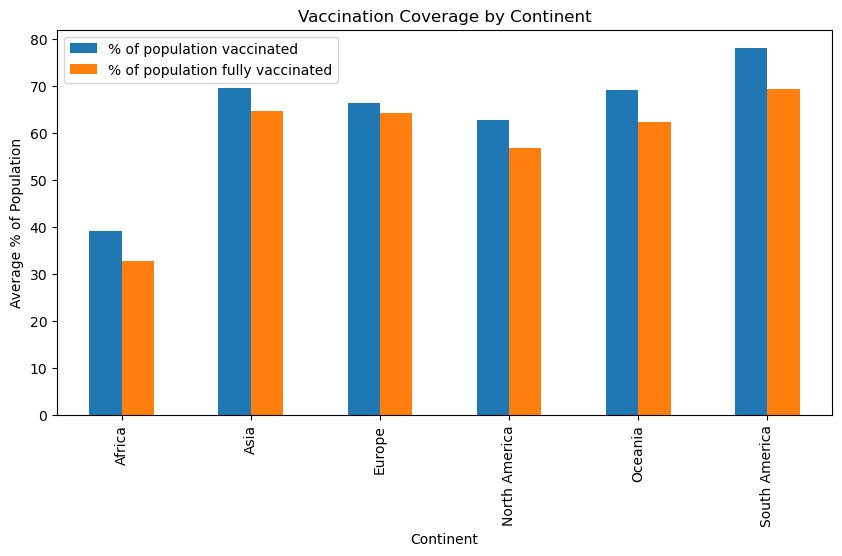

In [15]:
continent_avg.plot(kind="bar", figsize=(10,5))
plt.title("Vaccination Coverage by Continent")
plt.ylabel("Average % of Population")
plt.show()

Observation: The chart shows that vaccination coverage varies by continent, and in all cases less people took the second vaccination.

In [16]:
continent_avg["difference"] = (
    continent_avg["% of population vaccinated"] -
    continent_avg["% of population fully vaccinated"])

continent_avg

,% of population vaccinated,% of population fully vaccinated,difference
Continent,,,
Africa,39.073077,32.646154,6.426923
Asia,69.445652,64.686957,4.758696
Europe,66.342105,64.184211,2.157895
North America,62.742857,56.766667,5.976190
Oceania,69.109091,62.227273,6.881818
South America,78.000000,69.333333,8.666667


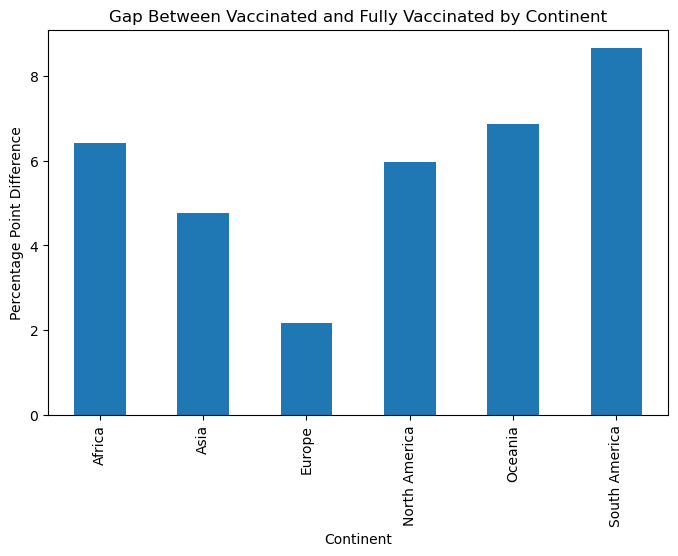

In [17]:
continent_avg["difference"].plot(kind="bar", figsize=(8,5))
plt.title("Gap Between Vaccinated and Fully Vaccinated by Continent")
plt.ylabel("Percentage Point Difference")
plt.show()

Observation: Possible reasons people did not get the second Covid Vaccine are side effect concerns,
reduced risk perception, and logisitcal barriers.

In [18]:
df2['country'] = df2['country'].replace({'USA': 'United States'})
df2['country'] = df2['country'].replace({'South-Africa': 'South Africa'})
df2['country'] = df2['country'].replace({'Ivory-Coast': 'Ivory Coast'})
df2['country'] = df2['country'].replace({'Cabo Verde': 'Cape Verde'})
df2['country'] = df2['country'].replace({'Burkina-Faso': 'Burkina Faso'})
df2['country'] = df2['country'].replace({'Sierra-Leone': 'Sierra Leone'})
df2['country'] = df2['country'].replace({'Sao-Tome-and-Principe': 'Sao Tome and Principe'})
df2['country'] = df2['country'].replace({'Equatorial-Guinea': 'Equatorial Guinea'})
df2['country'] = df2['country'].replace({'South-Sudan': 'South Sudan'})
df2['country'] = df2['country'].replace({'Saudi-Arabia': 'Saudi Arabia'})
df2['country'] = df2['country'].replace({'Sri-Lanka': 'Sri Lanka'})
df2['country'] = df2['country'].replace({'Hong-Kong': 'Hong Kong'})
df2['country'] = df2['country'].replace({'Macao': 'Macau'})
df2['country'] = df2['country'].replace({'S-Korea': 'South Korea'})
df2['country'] = df2['country'].replace({'UAE': 'U.A.E.'})
df2['country'] = df2['country'].replace({'Czechia': 'Czech Republic'})
df2['country'] = df2['country'].replace({'UK': 'U.K.'})
df2['country'] = df2['country'].replace({'North-Macedonia': 'North Macedonia'})
df2['country'] = df2['country'].replace({'Bosnia-and-Herzegovina': 'Bosnia and Herzegovina'})
df2['country'] = df2['country'].replace({'Turks-and-Caicos': 'Turkey'})
df2['country'] = df2['country'].replace({'Dominica': 'Dominican Rep.'})
df2['country'] = df2['country'].replace({'El-Salvador': 'El Salvador'})
df2['country'] = df2['country'].replace({'Dominican-Republic': 'Dominican Rep.'})
df2['country'] = df2['country'].replace({'Trinidad-and-Tobago': 'Trinidad and Tobago'})
df2['country'] = df2['country'].replace({'Costa-Rica': 'Costa Rica'})
df2['country'] = df2['country'].replace({'Papua-New-Guinea': 'Papua New Guinea'})
df2['country'] = df2['country'].replace({'New-Caledonia': 'New Caledonia'})
df2['country'] = df2['country'].replace({'New-Zealand': 'New Zealand'})

combined = pd.merge(
    df2,
    df3[['Country',
         '% of population vaccinated',
         '% of population fully vaccinated']],
    left_on='country',
    right_on='Country',
    how='left')

combined = combined.drop(columns=['Country'])
combined = combined.sort_values(by='continent')
combined = combined.reset_index()

combined.head()

,index,continent,country,cases.total,deaths.total,population(k),test.total (k),% of population vaccinated,% of population fully vaccinated
0,105,Africa,Egypt,516023,24613.0,106156.692,3693.367,54.0,40.0
1,102,Africa,Madagascar,68486,1426.0,29178.077,531.329,7.6,7.3
2,99,Africa,Eswatini,75191,1427.0,1184.817,1048.704,44.0,43.0
3,175,Africa,South Africa,4076463,102595.0,60756.135,26795.090,41.0,36.0
4,97,Africa,Ivory Coast,88384,835.0,27742.298,1690.934,51.0,45.0


In [19]:
analysis_df = combined.copy()

In [20]:
analysis_df = analysis_df.drop(columns=["index"])

In [21]:
analysis_df["cases_per_100k"] = (analysis_df["cases.total"] / (analysis_df["population(k)"] * 1000)) * 100000

analysis_df["deaths_per_100k"] = (analysis_df["deaths.total"] / (analysis_df["population(k)"] * 1000)) * 100000

analysis_df["fatality_rate"] = analysis_df["deaths.total"] / analysis_df["cases.total"]

analysis_df.head()

,continent,country,cases.total,deaths.total,population(k),test.total (k),% of population vaccinated,% of population fully vaccinated,cases_per_100k,deaths_per_100k,fatality_rate
0,Africa,Egypt,516023,24613.0,106156.692,3693.367,54.0,40.0,486.095592,23.185538,0.047697
1,Africa,Madagascar,68486,1426.0,29178.077,531.329,7.6,7.3,234.717319,4.887231,0.020822
2,Africa,Eswatini,75191,1427.0,1184.817,1048.704,44.0,43.0,6346.212115,120.440541,0.018978
3,Africa,South Africa,4076463,102595.0,60756.135,26795.090,41.0,36.0,6709.549579,168.863605,0.025168
4,Africa,Ivory Coast,88384,835.0,27742.298,1690.934,51.0,45.0,318.589325,3.009844,0.009447


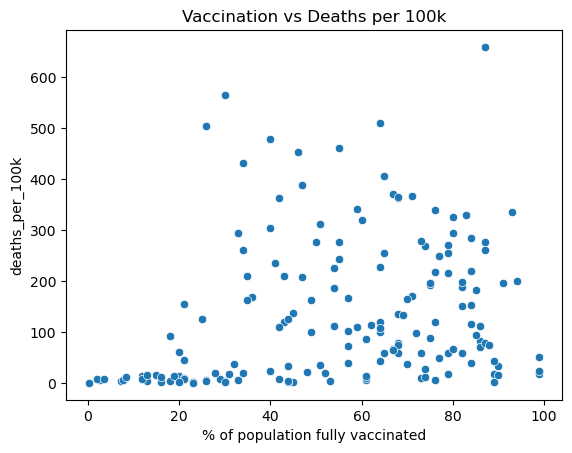

In [22]:
#Scatter: vaccination vs deaths

plt.figure()
sns.scatterplot(
    data=analysis_df,
    x='% of population fully vaccinated',
    y='deaths_per_100k')
plt.title('Vaccination vs Deaths per 100k')
plt.show()

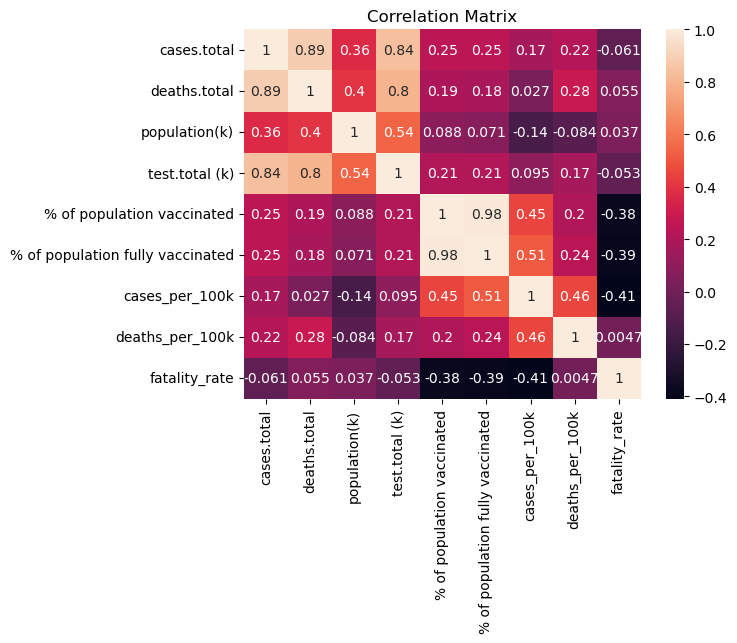

In [23]:
corr = analysis_df.corr(numeric_only=True)

plt.figure()
sns.heatmap(corr, annot=True)
plt.title("Correlation Matrix")
plt.show()

Observation1: Vaccination is moderately associated with case rates.
* % fully vaccinated ~ cases_per_100k = 0.51
* % vaccinated ~ cases_per_100k = 0.45

'Correlation does not imply causation', therefore, we cannot imply that vaccines increase cases.

Highly vaccinated areas may also be more densly populated.

Observation2: Vaccination is negatively correlated with fatality rate.
* % vaccinated ~ fatality_rate = -0.38
* % fully vaccinated ~ fatality_rate = -0.39

This suggest that higher vaccination levels are associated with lower fatality rates, meaning fewer deaths per case.

Observation3: Fatality rate is not strongely related to total cases or deaths.
* Correlation near zero 0

This indicates that fatality rate varies independently of total case counts and may depend on factors like:
* healthcare quality
* age distributioin
* vaccination coverage
* reporting differences



Ho = Vaccination rate has no replationship with deaths

H1 = Higher Vaccination reduces deaths

In [24]:
df = analysis_df[['% of population fully vaccinated', 'cases_per_100k', 'deaths_per_100k']].dropna()

X = df['% of population fully vaccinated']
y = df['deaths_per_100k']

X = sm.add_constant(X)

model2 = sm.OLS(y, X).fit()

print(model2.summary())

                            OLS Regression Results                            
Dep. Variable:        deaths_per_100k   R-squared:                       0.056
Model:                            OLS   Adj. R-squared:                  0.050
Method:                 Least Squares   F-statistic:                     9.957
Date:                Fri, 24 Apr 2026   Prob (F-statistic):            0.00190
Time:                        22:00:33   Log-Likelihood:                -1081.3
No. Observations:                 171   AIC:                             2167.
Df Residuals:                     169   BIC:                             2173.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                                       coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------------------
const   

1. Statistical Significance of the Model
   * F-statistic: 9.957
   * Prob (F-statistic): 0.00190
   * Because the p-value is <0.05, the regression model as a whole is statistically significant.
   * This means the independent variable provides some predictivie information about COVID deaths per 100k.

2. Significance of the Vaccination Variable
   * Coefficient: 1.2846
   * p-value: 0.002
   * 95% CI: 0.481 -> 2.088
   * Since the p-value is well below 0.05, the variable % of population fully vaccinated is statistically significant.

3. Interpretation of coefficient:
   * A 1 percentage point increase in vaccination rate is associated with an estimated increase of about 1.28 deaths per 100k.
   * However, this does not imply vaccines increase deaths - it simply shows a positive correlation in this dataset, which could be caused by factors like:
   * Older populations
   * Timing effects
   * Policy and reporting differences
   * Omitted variable

4. Model Strength (Goodness of Fit)
   * R-squared: 0.056
   * Adjusted R-squared: 0.050
   * This means the model explains only about 5.6% of the variation in deaths per 100k.
   * So, while the relationship is statistically significant, it is very weak in explanatory power.
     
5. The model detects a statistically significant replationship between vaccination rate and deaths per 100k, but the relationship is weak and likely influenced by missing variables, meaning storger models with additional predictors would be needed for meaningful conclusions.

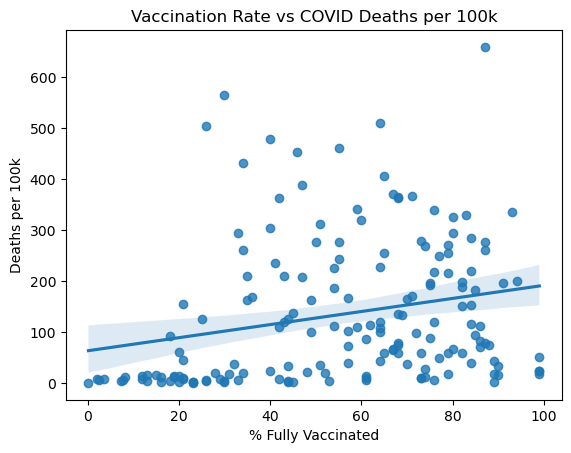

In [25]:
sns.regplot(
    x='% of population fully vaccinated',
    y='deaths_per_100k',
    data=df)

plt.title('Vaccination Rate vs COVID Deaths per 100k')
plt.xlabel('% Fully Vaccinated')
plt.ylabel('Deaths per 100k')
plt.show()

The scatterplot shows a weak positive relationship between vaccination rate and COVID deaths per 100,000 people. However, the wide spread of the data points and low R-squared value indicate that vaccination rates explain only a small portion of the variation in death rates. This suggests other factors, such as age distribution, healthcare quality, and infection rates, likely play a much larger role in determining COVID mortality.

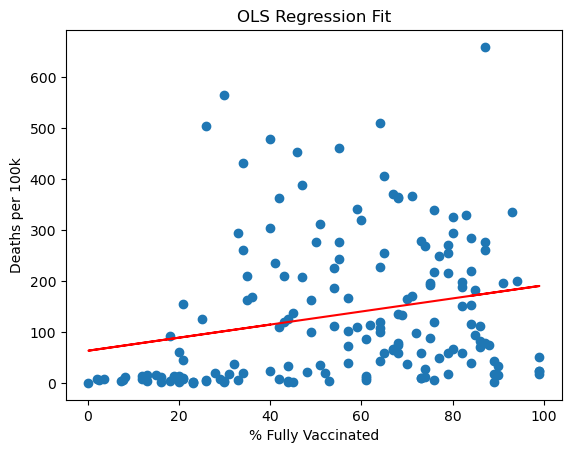

In [26]:
x = df['% of population fully vaccinated']
y = df['deaths_per_100k']

#predicted values
y_pred = model2.predict(sm.add_constant(x))

plt.scatter(x, y)
plt.plot(x, y_pred, color='red')

plt.xlabel('% Fully Vaccinated')
plt.ylabel('Deaths per 100k')
plt.title('OLS Regression Fit')

plt.show()

In [27]:
us_data = analysis_df[analysis_df['country'] == 'United States']
us_data

,continent,country,cases.total,deaths.total,population(k),test.total (k),% of population vaccinated,% of population fully vaccinated,cases_per_100k,deaths_per_100k,fatality_rate
150,North-America,United States,111820082,1219487.0,334805.269,1186851.502,80.0,68.0,33398.54308,364.237697,0.010906


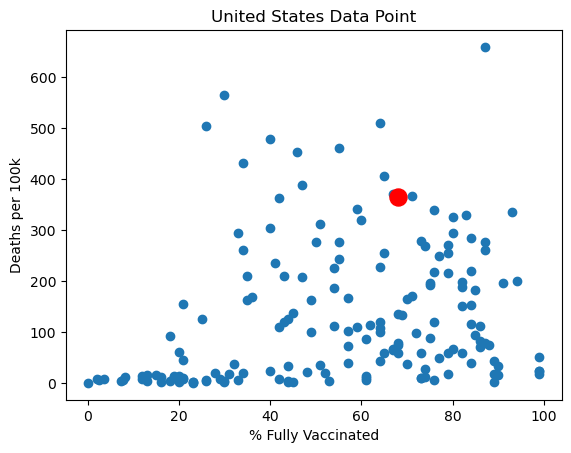

In [28]:
plt.scatter(analysis_df['% of population fully vaccinated'], analysis_df['deaths_per_100k'])

plt.scatter(us_data['% of population fully vaccinated'],
            us_data['deaths_per_100k'],
            color = 'red', s=150)

plt.xlabel('% Fully Vaccinated')
plt.ylabel('Deaths per 100k')
plt.title('United States Data Point')

plt.show()

1. The red dot represents the United States.
   * ~65-70% fully vaccinated
   * ~380 deaths per 100k
2. The U.S. sits above many other points with similar vaccination rates.
   * This means some countries with similar or higher vaccination levels have lower death rates.
   * The U.S. experienced relatively high deaths per 100k compared to many peers in the dataset.
3. However, the U.S. is not an extreme outlier.
4. This suggests that vaccination rate alone does not explain COVID death rates.